In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import re
import os
import imageio
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

In [ ]:
df1= r'/content/drive/MyDrive/cancer lungs/The IQ-OTHNCCD lung cancer dataset/The IQ-OTHNCCD lung cancer dataset'
df2=r'/content/drive/MyDrive/cancer lungs/Test cases'
categories = ['Bengin cases', 'Malignant cases', 'Normal cases']


In [ ]:
print(os.listdir(df1))
print(os.listdir(df2))

['Malignant cases', 'Normal cases', 'Bengin cases', 'IQ-OTH_NCCD lung cancer dataset.txt']
['000019_03_01_025.png', '000019_01_01_021.png', '000019_02_01_025.png']


Preparing Data

In [ ]:
import cv2
import random
from collections import Counter
import os
import numpy as np

data = []
img_size = 256

for i in categories:
    path = os.path.join(df1, i)
    class_num = categories.index(i)
    for file in os.listdir(path):
        filepath = os.path.join(path, file)
        img = cv2.imread(filepath, 0)
        # preprocess here
        img = cv2.resize(img, (img_size, img_size))
        data.append([img, class_num])

random.shuffle(data)

X, y = [], []
for feature, label in data:
    X.append(feature)
    y.append(label)

print('X length:', len(X))
print('y counts:', Counter(y))

# normalize
X = np.array(X).reshape(-1, img_size, img_size, 1)
X = X / 255.0
y = np.array(y)

X length: 1101
y counts: Counter({1: 561, 2: 420, 0: 120})


In [ ]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, random_state=10, stratify=y)

print(len(X_train), X_train.shape)
print(len(X_valid), X_valid.shape)


825 (825, 256, 256, 1)
276 (276, 256, 256, 1)


In [ ]:
import tensorflow as tf
import random
import numpy as np

SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seed(SEED)
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
print("X_train:", X_train.shape, X_train.dtype)
print("X_valid:", X_valid.shape, X_valid.dtype)

print("y_train shape:", np.shape(y_train))
print("y_valid shape:", np.shape(y_valid))

X_train: (825, 256, 256, 1) float64
X_valid: (276, 256, 256, 1) float64
y_train shape: (825,)
y_valid shape: (276,)


In [ ]:
import tensorflow as tf

def prepare_labels(y_train, y_valid):
    y_train = np.array(y_train)
    y_valid = np.array(y_valid)

    # case 1: already one-hot
    if y_train.ndim == 2 and y_train.shape[1] > 1:
        num_classes = y_train.shape[1]
        y_train_cat = y_train.astype(np.float32)
        y_valid_cat = y_valid.astype(np.float32)

        y_train_int = np.argmax(y_train_cat, axis=1)
        y_valid_int = np.argmax(y_valid_cat, axis=1)

    # case 2: integer labels
    else:
        y_train_int = y_train.astype(np.int32).reshape(-1)
        y_valid_int = y_valid.astype(np.int32).reshape(-1)

        num_classes = len(np.unique(y_train_int))
        y_train_cat = tf.keras.utils.to_categorical(y_train_int, num_classes=num_classes)
        y_valid_cat = tf.keras.utils.to_categorical(y_valid_int, num_classes=num_classes)

    return y_train_int, y_valid_int, y_train_cat, y_valid_cat, num_classes

y_train_int, y_valid_int, y_train_cat, y_valid_cat, NUM_CLASSES = prepare_labels(y_train, y_valid)

print("NUM_CLASSES:", NUM_CLASSES)
print("y_train_cat:", y_train_cat.shape)
print("y_valid_cat:", y_valid_cat.shape)


NUM_CLASSES: 3
y_train_cat: (825, 3)
y_valid_cat: (276, 3)


Normalize images

In [ ]:
def normalize_images(x):
    x = x.astype(np.float32)

    if x.max() > 1.0:
        x = x / 255.0

    return x

X_train = normalize_images(X_train)
X_valid = normalize_images(X_valid)

print(X_train.min(), X_train.max(), X_train.shape)
print(X_valid.min(), X_valid.max(), X_valid.shape)

0.0 1.0 (825, 256, 256, 1)
0.0 1.0 (276, 256, 256, 1)


visualization

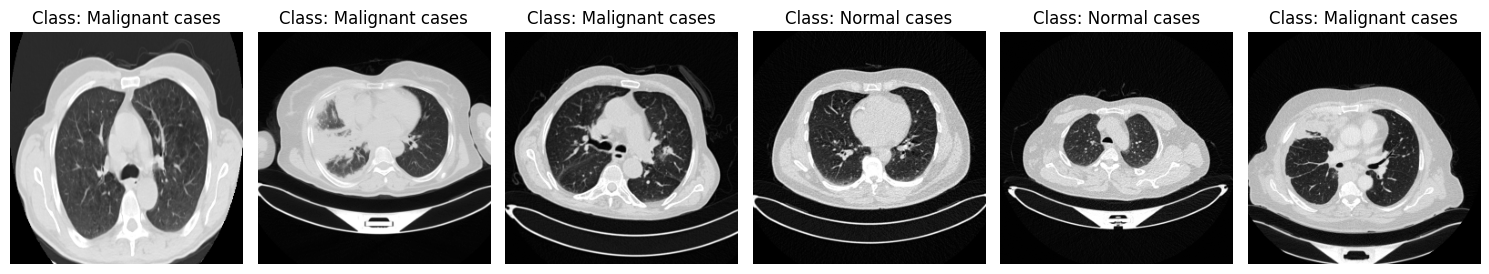

1


In [ ]:
def show_samples(images, labels, n=6):
    plt.figure(figsize=(15, 4))
    idxs = np.random.choice(len(images), n, replace=False)

    for i, idx in enumerate(idxs):
        # print(labels[idx])
        plt.subplot(1, n, i + 1)
        plt.imshow(images[idx].squeeze(), cmap='gray')
        plt.title(f"Class: {categories[labels[idx]]}")

        plt.axis("off")
    plt.tight_layout()
    plt.show()
    print(labels[idx])

show_samples(X_train, y_train_int, n=6)


Adaptive Gaussian-style denoising

In [ ]:
def adaptive_gaussian_filter(img, ksize=5):
    """
    img: (H, W) float32 in [0,1]
    returns denoised image in [0,1]
    """
    img_8 = (img * 255).astype(np.uint8)

    blurred = cv2.GaussianBlur(img_8, (ksize, ksize), 0)

    # local variance proxy
    lap = cv2.Laplacian(img_8, cv2.CV_32F)
    var_map = cv2.GaussianBlur(np.abs(lap), (ksize, ksize), 0)

    var_map = var_map / (var_map.max() + 1e-8)

    # higher texture => preserve original more
    # smoother/noisy flat regions => use more blur
    alpha = np.expand_dims(var_map, axis=-1) if var_map.ndim == 2 else var_map
    img_f = img_8.astype(np.float32) / 255.0
    blurred_f = blurred.astype(np.float32) / 255.0

    out = alpha[..., 0] * img_f + (1.0 - alpha[..., 0]) * blurred_f
    return np.clip(out, 0.0, 1.0).astype(np.float32)


Apply denoising

In [ ]:
from tqdm.notebook import tqdm

def apply_denoising_batch(x):
    out = []
    for img in tqdm(x, desc="Denoising"):
        den = adaptive_gaussian_filter(img.squeeze())
        out.append(den[..., np.newaxis])
    return np.array(out, dtype=np.float32)

X_train_denoised = apply_denoising_batch(X_train)
X_valid_denoised = apply_denoising_batch(X_valid)

print(X_train_denoised.shape, X_valid_denoised.shape)

Denoising:   0%|          | 0/825 [00:00<?, ?it/s]

Denoising:   0%|          | 0/276 [00:00<?, ?it/s]

(825, 256, 256, 1) (276, 256, 256, 1)


Compare original vs denoised

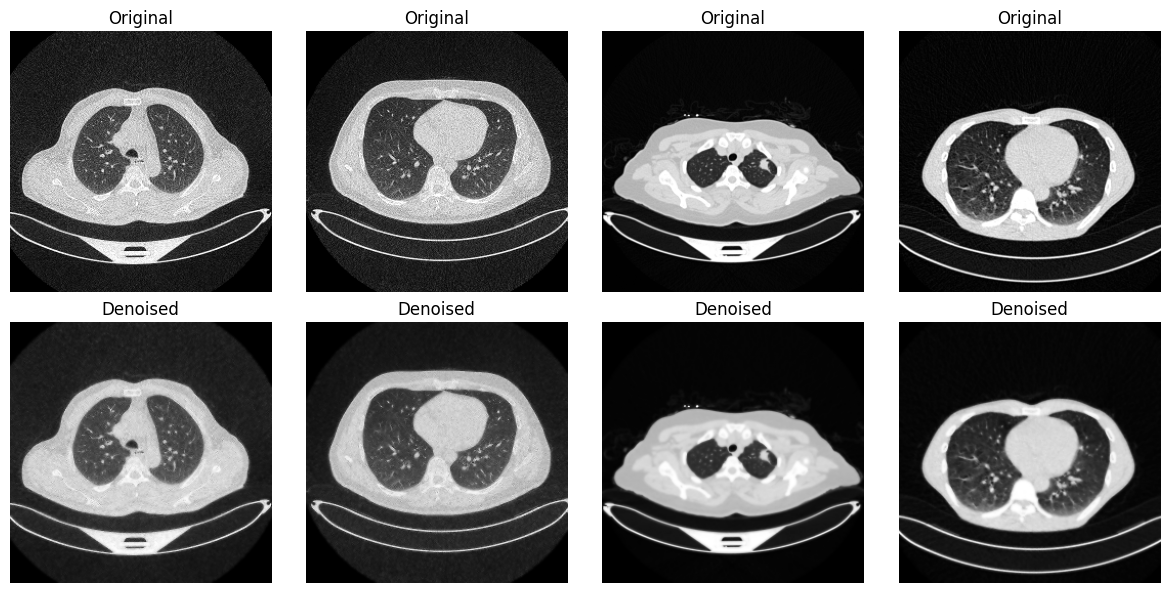

In [ ]:
def compare_original_denoised(x_orig, x_den, n=4):
    idxs = np.random.choice(len(x_orig), n, replace=False)
    plt.figure(figsize=(12, 6))

    for i, idx in enumerate(idxs):
        plt.subplot(2, n, i + 1)
        plt.imshow(x_orig[idx].squeeze(), cmap='gray')
        plt.title("Original")
        plt.axis("off")

        plt.subplot(2, n, n + i + 1)
        plt.imshow(x_den[idx].squeeze(), cmap='gray')
        plt.title("Denoised")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


compare_original_denoised(X_train, X_train_denoised, n=4)



GLCM + LBP handcrafted features

In [ ]:
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern

def extract_glcm_lbp_features_single(img, distances=[1, 2], angles=None, lbp_points=8, lbp_radius=1):
    """
    img: (H, W) float32 in [0,1]
    """
    if angles is None:
        angles = [0, np.pi/4, np.pi/2, 3*np.pi/4]

    img_8 = (img * 255).astype(np.uint8)

    # GLCM
    glcm = graycomatrix(
        img_8,
        distances=distances,
        angles=angles,
        levels=256,
        symmetric=True,
        normed=True
    )

    glcm_feats = []
    for prop in ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation', 'ASM']:
        vals = graycoprops(glcm, prop).flatten()
        glcm_feats.extend(vals.tolist())

    # LBP
    lbp = local_binary_pattern(img_8, P=lbp_points, R=lbp_radius, method='uniform')
    n_bins = lbp_points + 2
    lbp_hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, n_bins + 1), range=(0, n_bins))
    lbp_hist = lbp_hist.astype(np.float32)
    lbp_hist /= (lbp_hist.sum() + 1e-8)

    feats = np.concatenate([np.array(glcm_feats, dtype=np.float32), lbp_hist], axis=0)
    return feats.astype(np.float32)

Batch feature extraction

In [ ]:
def extract_features_batch(x):
    feats = []
    for img in tqdm(x, desc="Extracting GLCM+LBP"):
        f = extract_glcm_lbp_features_single(img.squeeze())
        feats.append(f)
    return np.array(feats, dtype=np.float32)

X_train_feats = extract_features_batch(X_train_denoised)
X_valid_feats = extract_features_batch(X_valid_denoised)

print("Handcrafted feature shape:", X_train_feats.shape, X_valid_feats.shape)

Extracting GLCM+LBP:   0%|          | 0/825 [00:00<?, ?it/s]

Extracting GLCM+LBP:   0%|          | 0/276 [00:00<?, ?it/s]

Handcrafted feature shape: (825, 58) (276, 58)


Standardize handcrafted features

In [ ]:
train_mean = X_train_feats.mean(axis=0, keepdims=True)
train_std = X_train_feats.std(axis=0, keepdims=True) + 1e-8

X_train_feats_std = (X_train_feats - train_mean) / train_std
X_valid_feats_std = (X_valid_feats - train_mean) / train_std

print(X_train_feats_std.shape, X_valid_feats_std.shape)

(825, 58) (276, 58)


Class weights

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_int),
    y=y_train_int
)

class_weight_dict = {i: w for i, w in enumerate(class_weights)}
print(class_weight_dict)

{0: np.float64(3.0555555555555554), 1: np.float64(0.6547619047619048), 2: np.float64(0.873015873015873)}


MSCA block

In [ ]:
def channel_attention(x, ratio=8, name="ca"):
    channels = x.shape[-1]
    avg_pool = layers.GlobalAveragePooling2D(name=f"{name}_gap")(x)
    max_pool = layers.GlobalMaxPooling2D(name=f"{name}_gmp")(x)

    shared_dense_1 = layers.Dense(channels // ratio, activation='relu', name=f"{name}_fc1")
    shared_dense_2 = layers.Dense(channels, activation=None, name=f"{name}_fc2")

    avg_out = shared_dense_2(shared_dense_1(avg_pool))
    max_out = shared_dense_2(shared_dense_1(max_pool))

    out = layers.Add(name=f"{name}_add")([avg_out, max_out])
    out = layers.Activation('sigmoid', name=f"{name}_sigmoid")(out)
    out = layers.Reshape((1, 1, channels), name=f"{name}_reshape")(out)

    return layers.Multiply(name=f"{name}_scale")([x, out])


def spatial_attention(x, name="sa"):
    avg_pool = tf.reduce_mean(x, axis=-1, keepdims=True)
    max_pool = tf.reduce_max(x, axis=-1, keepdims=True)

    concat = layers.Concatenate(axis=-1, name=f"{name}_concat")([avg_pool, max_pool])
    out = layers.Conv2D(1, kernel_size=7, padding='same', activation='sigmoid', name=f"{name}_conv")(concat)

    return layers.Multiply(name=f"{name}_scale")([x, out])


def msca_block(x, ratio=8, name="msca"):
    x = channel_attention(x, ratio=ratio, name=f"{name}_channel")
    x = spatial_attention(x, name=f"{name}_spatial")
    return x


In [ ]:
def channel_attention(x, ratio=8, name="ca"):
    channels = x.shape[-1]

    avg_pool = layers.GlobalAveragePooling2D(name=f"{name}_gap")(x)
    max_pool = layers.GlobalMaxPooling2D(name=f"{name}_gmp")(x)

    shared_dense_1 = layers.Dense(max(channels // ratio, 1), activation='relu', name=f"{name}_fc1")
    shared_dense_2 = layers.Dense(channels, activation=None, name=f"{name}_fc2")

    avg_out = shared_dense_2(shared_dense_1(avg_pool))
    max_out = shared_dense_2(shared_dense_1(max_pool))

    out = layers.Add(name=f"{name}_add")([avg_out, max_out])
    out = layers.Activation('sigmoid', name=f"{name}_sigmoid")(out)
    out = layers.Reshape((1, 1, channels), name=f"{name}_reshape")(out)

    out = layers.Multiply(name=f"{name}_scale")([x, out])
    return out


def spatial_attention(x, name="sa"):
    avg_pool = layers.Lambda(
        lambda z: tf.reduce_mean(z, axis=-1, keepdims=True),
        name=f"{name}_avgpool"
    )(x)

    max_pool = layers.Lambda(
        lambda z: tf.reduce_max(z, axis=-1, keepdims=True),
        name=f"{name}_maxpool"
    )(x)

    concat = layers.Concatenate(axis=-1, name=f"{name}_concat")([avg_pool, max_pool])

    out = layers.Conv2D(
        filters=1,
        kernel_size=7,
        padding='same',
        activation='sigmoid',
        name=f"{name}_conv"
    )(concat)

    out = layers.Multiply(name=f"{name}_scale")([x, out])
    return out


def msca_block(x, ratio=8, name="msca"):
    x = channel_attention(x, ratio=ratio, name=f"{name}_channel")
    x = spatial_attention(x, name=f"{name}_spatial")
    return x

Build the hybrid model

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model

def build__model(input_shape=(256, 256, 1), feature_dim=None, num_classes=3, train_base=False):
    # image input
    img_input = layers.Input(shape=input_shape, name="image_input")

    # handcrafted feature input
    feat_input = layers.Input(shape=(feature_dim,), name="handcrafted_input")

    # grayscale -> rgb
    x = layers.Concatenate(name="gray_to_rgb")([img_input, img_input, img_input])

    # resize for InceptionV3
    x = layers.Resizing(224, 224, name="resize_224")(x)

    # base model
    base_model = tf.keras.applications.InceptionV3(
        include_top=False,
        weights="imagenet",
        input_tensor=x
    )
    base_model.trainable = train_base

    # choose a feature map from InceptionV3
    feat_map = base_model.get_layer("mixed7").output

    # MSCA block
    x = msca_block(feat_map, ratio=8, name="msca")

    # deeper conv refinement
    x = layers.Conv2D(256, 3, padding='same', activation='relu', name="refine_conv1")(x)
    x = layers.BatchNormalization(name="refine_bn1")(x)
    x = layers.Conv2D(256, 3, padding='same', activation='relu', name="refine_conv2")(x)
    x = layers.BatchNormalization(name="refine_bn2")(x)

    # this layer will be useful for Grad-CAM
    x = layers.Conv2D(128, 3, padding='same', activation='relu', name="gradcam_target")(x)

    deep_feat = layers.GlobalAveragePooling2D(name="deep_gap")(x)
    deep_feat = layers.Dropout(0.3, name="deep_dropout")(deep_feat)

    # handcrafted branch
    h = layers.Dense(128, activation='relu', name="hand_fc1")(feat_input)
    h = layers.BatchNormalization(name="hand_bn1")(h)
    h = layers.Dropout(0.3, name="hand_dropout1")(h)

    h = layers.Dense(64, activation='relu', name="hand_fc2")(h)
    h = layers.BatchNormalization(name="hand_bn2")(h)

    # fusion
    fused = layers.Concatenate(name="feature_fusion")([deep_feat, h])

    # MLP classifier
    z = layers.Dense(256, activation='relu', name="mlp_fc1")(fused)
    z = layers.BatchNormalization(name="mlp_bn1")(z)
    z = layers.Dropout(0.4, name="mlp_dropout1")(z)

    z = layers.Dense(128, activation='relu', name="mlp_fc2")(z)
    z = layers.BatchNormalization(name="mlp_bn2")(z)
    z = layers.Dropout(0.3, name="mlp_dropout2")(z)

    output = layers.Dense(num_classes, activation='softmax', name="prediction")(z)

    model = Model(inputs=[img_input, feat_input], outputs=output, name="PaperLike_MSCA_Inception_GLCM_LBP_MLP")
    return model

model = build__model(
    input_shape=(256, 256, 1),
    feature_dim=X_train_feats_std.shape[1],
    num_classes=NUM_CLASSES,
    train_base=False
)

model.summary()

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "PaperLike_MSCA_Inception_GLCM_LBP_MLP"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gray_to_rgb         │ (None, 256, 256,  │          0 │ image_input[0][0… │
│ (Concatenate)       │ 3)                │            │ image_input[0][0… │
│                     │                   │            │ image_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resize_224          │ (None, 224, 224,  │          0 │ gray_to_rgb[0][0] │
│ (Resizing)          │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 111, 111,  │        864 │ resize_224[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 111, 111,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 111, 111,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 109, 109,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 109, 109,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 54, 54,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 54, 54,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 54, 54,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 54, 54,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 11,881,382 (45.32 MB)

 Trainable params: 2,903,942 (11.08 MB)

 Non-trainable params: 8,977,440 (34.25 MB)

Compile model

In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

Callbacks

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        "best__model.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

Train model

In [ ]:
history = model.fit(
    x=[X_train_denoised, X_train_feats_std],
    y=y_train_cat,
    validation_data=([X_valid_denoised, X_valid_feats_std], y_valid_cat),
    epochs=30,
    batch_size=16,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step - accuracy: 0.3640 - auc: 0.5508 - loss: 1.7121 - precision: 0.3743 - recall: 0.3242
Epoch 1: val_loss improved from None to 1.02977, saving model to best__model.keras

Epoch 1: finished saving model to best__model.keras
52/52 ━━━━━━━━━━━━━━━━━━━━ 57s 590ms/step - accuracy: 0.4509 - auc: 0.6264 - loss: 1.4382 - precision: 0.4630 - recall: 0.4024 - val_accuracy: 0.4710 - val_auc: 0.6762 - val_loss: 1.0298 - val_precision: 0.3750 - val_recall: 0.0217 - learning_rate: 1.0000e-04
Epoch 2/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.6117 - auc: 0.8051 - loss: 0.9783 - precision: 0.6334 - recall: 0.5664
Epoch 2: val_loss improved from 1.02977 to 0.94188, saving model to best__model.keras

Epoch 2: finished saving model to best__model.keras
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - accuracy: 0.6424 - auc: 0.8228 - loss: 0.9553 - precision: 0.6618 - recall: 0.6000 - val_accuracy: 0.5000 - val_auc: 0.7638 - val_loss: 0.9419 - val_p

Plot training history

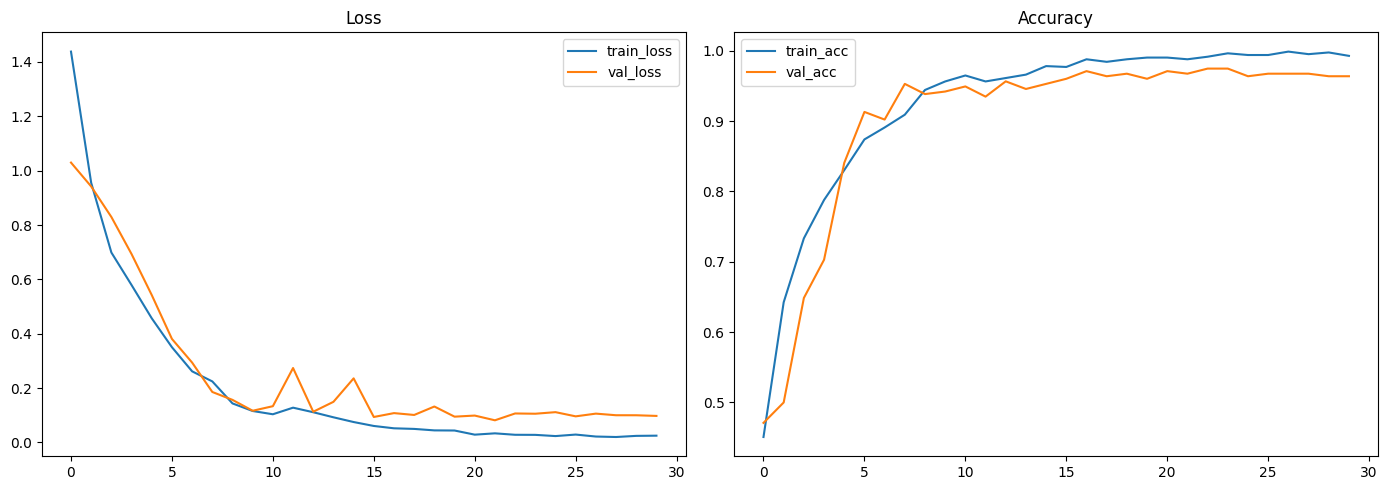

In [ ]:
def plot_history(history):
    hist = history.history
    keys = [k for k in hist.keys() if not k.startswith("val_")]

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(hist["loss"], label="train_loss")
    plt.plot(hist["val_loss"], label="val_loss")
    plt.legend()
    plt.title("Loss")

    plt.subplot(1, 2, 2)
    plt.plot(hist["accuracy"], label="train_acc")
    plt.plot(hist["val_accuracy"], label="val_acc")
    plt.legend()
    plt.title("Accuracy")

    plt.tight_layout()
    plt.show()

plot_history(history)

Evaluate model

In [ ]:
results = model.evaluate(
    [X_valid_denoised, X_valid_feats_std],
    y_valid_cat,
    verbose=1
)

for name, value in zip(model.metrics_names, results):
    print(f"{name}: {value:.4f}")

9/9 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.9674 - auc: 0.9966 - loss: 0.0812 - precision: 0.9745 - recall: 0.9674
loss: 0.0812
compile_metrics: 0.9674


Predictions and report

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
y_pred_prob = model.predict([X_valid_denoised, X_valid_feats_std], verbose=1)
y_pred = np.argmax(y_pred_prob, axis=1)

print(classification_report(y_valid_int, y_pred, digits=4))
print("Confusion Matrix:\n", confusion_matrix(y_valid_int, y_pred))

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step
              precision    recall  f1-score   support

           0     0.8710    0.9000    0.8852        30
           1     0.9860    1.0000    0.9930       141
           2     0.9706    0.9429    0.9565       105

    accuracy                         0.9674       276
   macro avg     0.9425    0.9476    0.9449       276
weighted avg     0.9676    0.9674    0.9674       276

Confusion Matrix:
 [[ 27   0   3]
 [  0 141   0]
 [  4   2  99]]


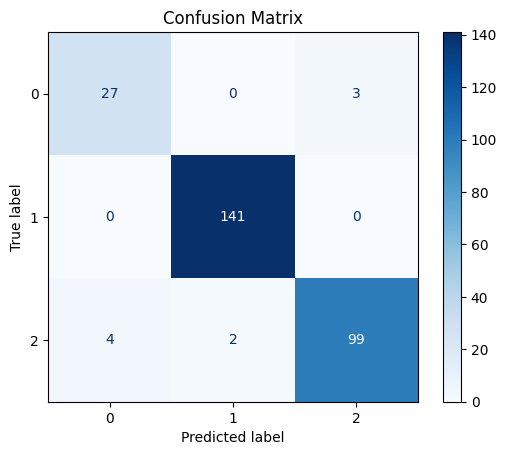

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_valid_int, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title("Confusion Matrix")
plt.show()

ROC-AUC

In [ ]:
from sklearn.metrics import roc_auc_score

try:
    auc_score = roc_auc_score(y_valid_cat, y_pred_prob, multi_class='ovr')
    print("Validation ROC-AUC:", round(auc_score, 4))
except Exception as e:
    print("ROC-AUC could not be computed:", e)

Validation ROC-AUC: 0.9973


Grad-CAM helper

In [ ]:
def make_gradcam_heatmap(model, image_array, feature_array, last_conv_layer_name="gradcam_target", class_index=None):
    """
    image_array: shape (1, 256, 256, 1)
    feature_array: shape (1, feat_dim)
    """
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, preds = grad_model([image_array, feature_array], training=False)

        if class_index is None:
            class_index = tf.argmax(preds[0])

        class_channel = preds[:, class_index]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(tf.multiply(pooled_grads, conv_outputs), axis=-1)

    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    heatmap = heatmap.numpy()

    return heatmap, int(class_index.numpy() if hasattr(class_index, "numpy") else class_index), preds.numpy()[0]

overlay heatmap on image

In [ ]:
def overlay_gradcam(image, heatmap, alpha=0.4):
    """
    image: (256,256) float in [0,1]
    heatmap: smaller map from conv layer
    """
    heatmap_resized = cv2.resize(heatmap, (image.shape[1], image.shape[0]))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    image_rgb = np.stack([image, image, image], axis=-1)
    image_rgb = np.uint8(255 * image_rgb)

    overlay = cv2.addWeighted(image_rgb, 1 - alpha, heatmap_color, alpha, 0)
    return heatmap_resized, overlay

Display Grad-CAM for one image

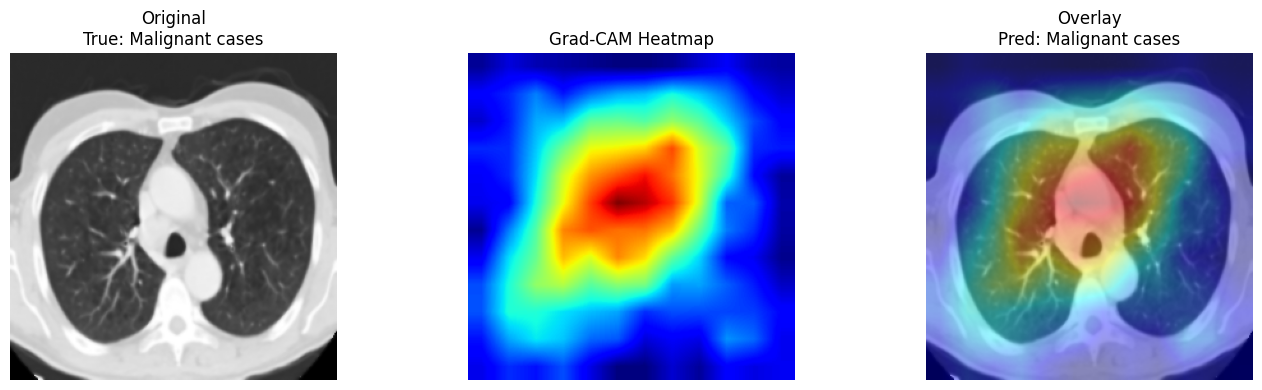

Predicted probabilities:
Bengin cases: 0.0012
Malignant cases: 0.9988
Normal cases: 0.0000


In [ ]:
# class_names = [f"Class_{i}" for i in range(NUM_CLASSES)]
class_names = categories

def show_gradcam_for_index(model, x_images, x_feats, y_true_int, index):
    image = x_images[index:index+1]
    feat = x_feats[index:index+1]

    heatmap, pred_class, pred_probs = make_gradcam_heatmap(
        model=model,
        image_array=image,
        feature_array=feat,
        last_conv_layer_name="gradcam_target",
        class_index=None
    )

    heatmap_resized, overlay = overlay_gradcam(image[0].squeeze(), heatmap, alpha=0.4)

    plt.figure(figsize=(14, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(image[0].squeeze(), cmap='gray')
    plt.title(f"Original\nTrue: {class_names[y_true_int[index]]}")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(heatmap_resized, cmap='jet')
    plt.title("Grad-CAM Heatmap")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title(f"Overlay\nPred: {class_names[pred_class]}")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    print("Predicted probabilities:")
    for i, p in enumerate(pred_probs):
        print(f"{class_names[i]}: {p:.4f}")

sample_idx = 0
show_gradcam_for_index(model, X_valid_denoised, X_valid_feats_std, y_valid_int, sample_idx)


Show Grad-CAM for random validation samples

Index: 227


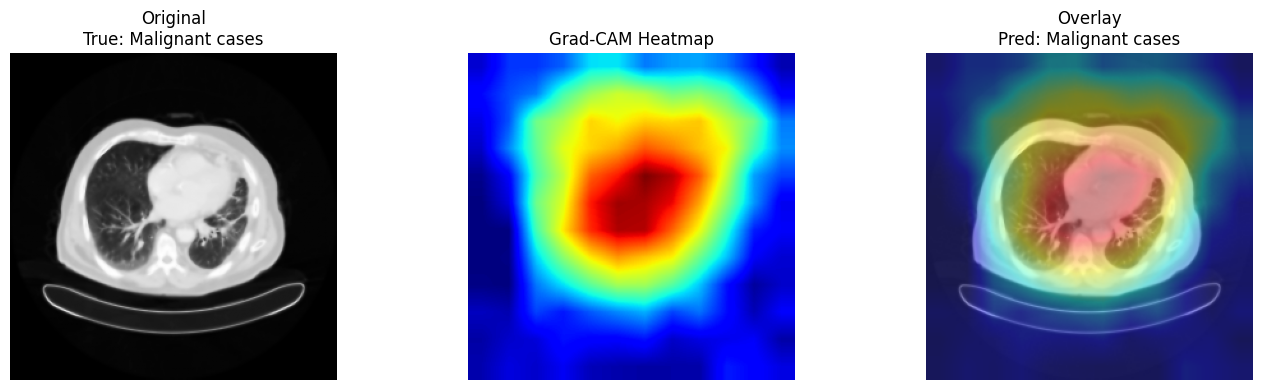

Predicted probabilities:
Bengin cases: 0.0003
Malignant cases: 0.9997
Normal cases: 0.0000
Index: 37


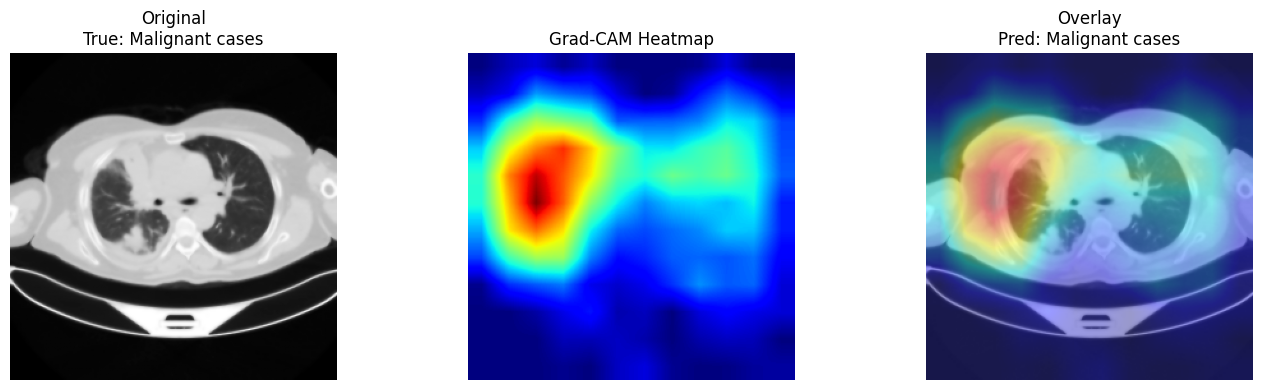

Predicted probabilities:
Bengin cases: 0.0002
Malignant cases: 0.9998
Normal cases: 0.0000
Index: 154


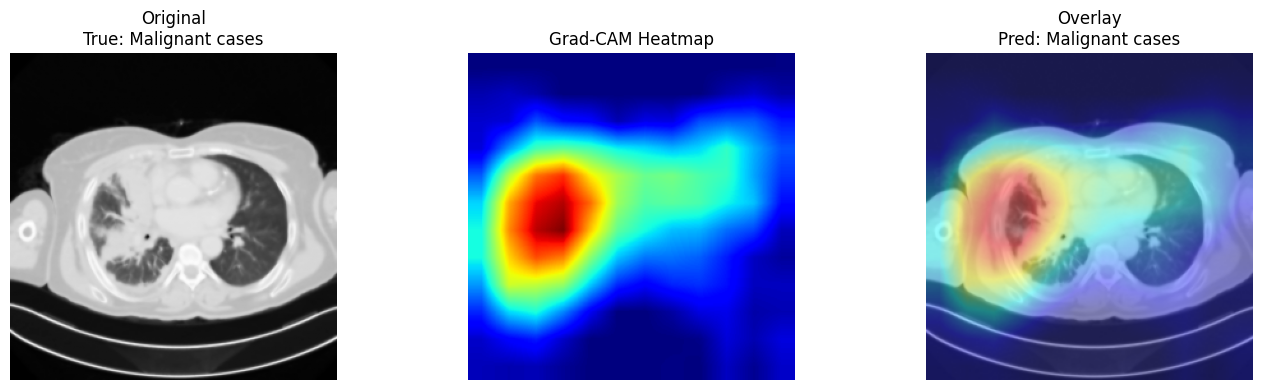

Predicted probabilities:
Bengin cases: 0.0006
Malignant cases: 0.9994
Normal cases: 0.0000
Index: 221


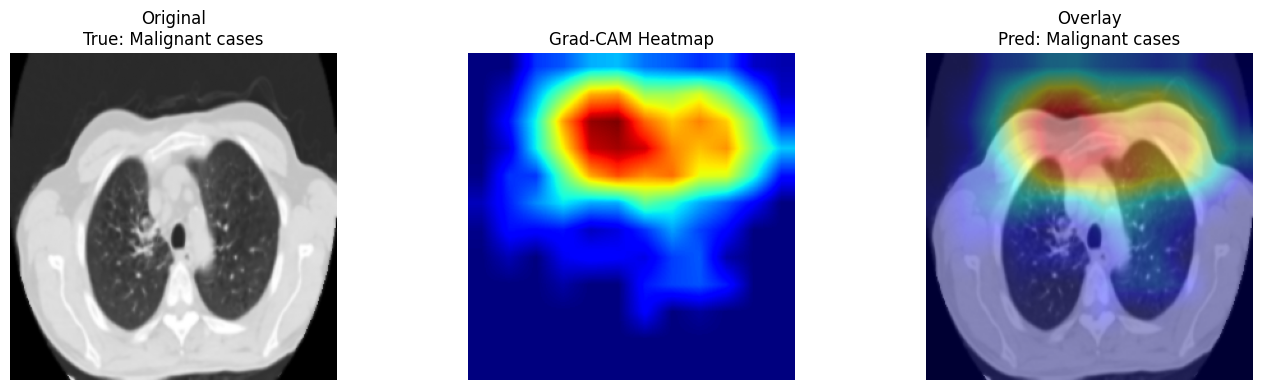

Predicted probabilities:
Bengin cases: 0.0034
Malignant cases: 0.9963
Normal cases: 0.0002
Index: 90


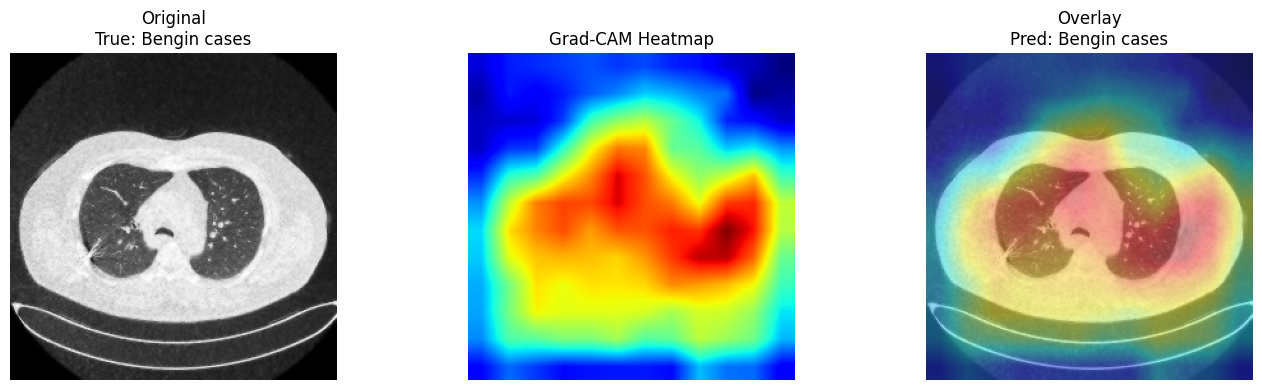

Predicted probabilities:
Bengin cases: 1.0000
Malignant cases: 0.0000
Normal cases: 0.0000


In [ ]:
rand_idxs = np.random.choice(len(X_valid_denoised), 5, replace=False)

for idx in rand_idxs:
    print("=" * 70)
    print("Index:", idx)
    show_gradcam_for_index(model, X_valid_denoised, X_valid_feats_std, y_valid_int, idx)